<a href="https://colab.research.google.com/github/anushreesingh0701-droid/Hospital-Readmission-/blob/main/Hospital_Readmission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [11]:
df = pd.read_csv("/content/diabetic_data.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 101766
Columns: 50


In [12]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [13]:
df["readmitted"].value_counts()

,count
readmitted,
NO,54864
>30,35545
<30,11357


In [14]:
df["readmitted_30"] = (df["readmitted"] == "<30").astype(int)

In [15]:
df["readmitted_30"].value_counts()

,count
readmitted_30,
0,90409
1,11357


In [16]:
df = df.replace("?", np.nan)

In [17]:
missing = df.isnull().sum().sort_values(ascending=False)

missing.head(15)

,0
weight,98569
max_glu_serum,96420
A1Cresult,84748
medical_specialty,49949
payer_code,40256
race,2273
diag_3,1423
diag_2,358
diag_1,21
patient_nbr,0


In [18]:
df = df.drop(
    columns=["encounter_id", "patient_nbr", "readmitted"]
)

print("Columns remaining:", df.shape[1])

Columns remaining: 48


In [19]:
missing_percentage = df.isnull().mean() * 100

columns_to_drop = missing_percentage[
    missing_percentage > 40
].index

print("Columns being removed:")
print(list(columns_to_drop))

df = df.drop(columns=columns_to_drop)

print("New dataset shape:", df.shape)

Columns being removed:
['weight', 'medical_specialty', 'max_glu_serum', 'A1Cresult']
New dataset shape: (101766, 44)


In [20]:
X = df.drop("readmitted_30", axis=1)
y = df["readmitted_30"]

print("Features (X):", X.shape)
print("Target (y):", y.shape)

Features (X): (101766, 43)
Target (y): (101766,)


In [21]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Number of numerical features: 11
Number of categorical features: 32


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (81412, 43)
Testing data: (20354, 43)


In [23]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [24]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [25]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [26]:
model = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=2000,
    solver="liblinear"
)

In [27]:
clf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

In [28]:
clf.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [29]:
y_pred = clf.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [30]:
y_prob = clf.predict_proba(X_test)[:, 1]

print(y_prob[:10])

[0.13957461 0.06145372 0.14024512 0.24651256 0.11609668 0.03162108
 0.05472522 0.05814117 0.25532343 0.19360394]


In [31]:
y_prob = clf.predict_proba(X_test)[:, 1]

print(y_prob[:10])

[0.13957461 0.06145372 0.14024512 0.24651256 0.11609668 0.03162108
 0.05472522 0.05814117 0.25532343 0.19360394]


In [32]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8882774884543578


In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.48      0.02      0.04      2271

    accuracy                           0.89     20354
   macro avg       0.69      0.51      0.49     20354
weighted avg       0.84      0.89      0.84     20354



In [34]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.6441067660683857


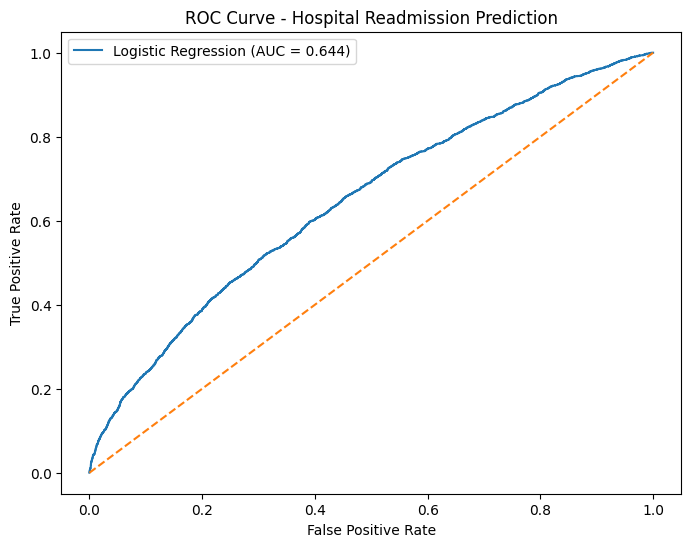

In [35]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hospital Readmission Prediction")
plt.legend()

plt.show()

In [36]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[18036    47]
 [ 2227    44]]


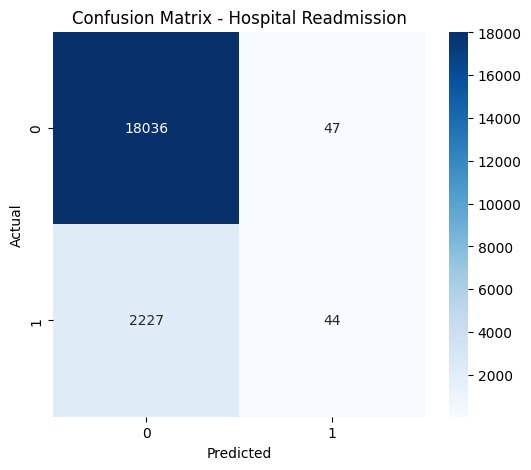

In [37]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Hospital Readmission")

plt.show()

In [38]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 18036
False Positives: 47
False Negatives: 2227
True Positives : 44


In [39]:
fn_rate = fn / (fn + tp)
fp_rate = fp / (fp + tn)

print("False Negative Rate:", fn_rate)
print("False Positive Rate:", fp_rate)

False Negative Rate: 0.980625275209159
False Positive Rate: 0.002599126251175137


In [40]:
print("Hospital Readmission Prediction")
print("--------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"False Positives : {fp}")
print(f"False Negatives : {fn}")

Hospital Readmission Prediction
--------------------------------
Accuracy : 0.8883
ROC-AUC  : 0.6441
False Positives : 47
False Negatives : 2227
